In [48]:
import os
import librosa
import numpy as np
import pandas as pd
import pyloudnorm as pyln
import matplotlib.pyplot as plt
import seaborn as sns
import msaf
from tqdm import tqdm

sns.set(style="darkgrid")

In [49]:
def extract_features(filepath):
    y, sr = librosa.load(filepath, sr=None)
    
    features = {}
    
    features["duration"] = librosa.get_duration(y=y, sr=sr)
    
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    features["tempo"] = float(np.mean(tempo))
    
    features["rms_mean"] = np.mean(librosa.feature.rms(y=y))
    features["spectral_centroid_mean"] = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    features["spectral_bandwidth_mean"] = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    features["spectral_rolloff_mean"] = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    features["zcr_mean"] = np.mean(librosa.feature.zero_crossing_rate(y))
    
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    features["chroma_mean"] = np.mean(chroma)
    features["chroma_std"] = np.std(chroma)
    
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for i in range(13):
        features[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
        features[f"mfcc_{i+1}_std"] = np.std(mfcc[i])
    
    return features

In [50]:
def structural_features(filepath):
    boundaries, labels = msaf.process(filepath, boundaries_id="foote")
    
    segment_lengths = np.diff(boundaries)
    labels_array = np.array(labels)
    non_negative_labels = labels_array[labels_array != -1]
    unique_labels = set(labels_array)
    
    entropy = 0
    for l in unique_labels:
        if l != -1:
            p = list(labels_array).count(l) / len(labels_array)
            entropy += -p * np.log2(p)
    
    return {
        "num_segments": len(segment_lengths),
        "avg_segment_length": np.mean(segment_lengths),
        "segment_length_std": np.std(segment_lengths),
        "num_structured_sections": len(non_negative_labels),
        "structure_ratio": len(non_negative_labels) / len(labels_array),
        "unique_sections": len(unique_labels) - (1 if -1 in unique_labels else 0),
        "label_entropy": entropy
    }

In [51]:
def loudness_features(filepath):
    y, sr = librosa.load(filepath, sr=None, mono=True)
    
    # Integrated LUFS (perceptual loudness, frequency-weighted RMS)
    meter = pyln.Meter(sr)
    lufs = meter.integrated_loudness(y)
    
    # Raw RMS in dB
    rms = np.sqrt(np.mean(y**2))
    
    # Crest factor: peak-to-RMS ratio in dB
    # A direct fingerprint of dynamic range compression
    peak = np.max(np.abs(y))
    crest_db = 20 * np.log10(peak / rms) if rms > 0 else np.nan
    
    return {"lufs": lufs, "crest_db": crest_db}

In [52]:
base_folder = "song_mp3"
rows = []

CHECKPOINT = "checkpoint.csv"

# Load already-processed songs if checkpoint exists
if os.path.exists(CHECKPOINT):
    df_done = pd.read_csv(CHECKPOINT)
    done_files = set(df_done["song"].tolist())
    rows = df_done.to_dict("records")
    print(f"Resuming — {len(done_files)} songs already done")
else:
    done_files = set()
    rows = []

all_files = [
    (os.path.join(base_folder, d, f), f, d)
    for d in os.listdir(base_folder)
    if os.path.isdir(os.path.join(base_folder, d))
    for f in os.listdir(os.path.join(base_folder, d))
    if f.endswith(".mp3")
]

for filepath, file, decade in tqdm(all_files, desc="Processing songs"):
    if file in done_files:
        continue  # skip already processed
    try:
        audio_feats = extract_features(filepath)
        struct_feats = structural_features(filepath)
        combined = {**audio_feats, **struct_feats}
        combined["song"] = file
        combined["decade"] = decade
        rows.append(combined)

        # Save after every song
        pd.DataFrame(rows).to_csv(CHECKPOINT, index=False)
    except Exception as e:
        print(f"Skipping {file}: {e}")

df_all = pd.DataFrame(rows)

df_all.head()

Resuming — 140 songs already done


Processing songs: 100%|██████████| 140/140 [00:00<00:00, 632761.38it/s]


,duration,tempo,rms_mean,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,zcr_mean,chroma_mean,chroma_std,mfcc_1_mean,...,structure_ratio,unique_sections,label_entropy,song,decade,lufs_x,rms_db,crest_db_x,lufs_y,crest_db_y
0,233.662404,90.666118,0.101435,3532.023367,3400.499152,7283.451094,0.092805,0.445509,0.287692,-149.24602,...,0.111111,1,0.352214,NA-I'm So Excited.mp3.mp3,1980,-18.368246,-18.993078,17.722642,-18.368246,17.722642
1,244.831202,107.666016,0.200271,3032.832943,3191.841067,6020.687270,0.073226,0.485379,0.295696,-118.66423,...,0.083333,1,0.298747,NA-Upside Down.mp3.mp3,1980,-12.947341,-12.473273,15.844059,-12.947341,15.844059
2,207.818594,126.048018,0.068001,3944.613535,3428.667403,7581.554409,0.116745,0.450424,0.287771,-176.66197,...,0.100000,1,0.332193,John Mellencamp - Hurts So Good (Official Musi...,1980,-20.713826,-22.299420,19.170363,-20.713826,19.170363
3,268.515556,93.963068,0.168164,1954.540437,2640.015986,3519.936235,0.045724,0.373673,0.299095,-172.67389,...,0.090909,1,0.314494,NA-Endless Love.mp3.mp3,1980,-14.328760,-14.470978,14.477715,-14.328760,14.477715
4,215.388299,90.666118,0.108002,2075.257282,2769.695049,4295.092338,0.041444,0.406748,0.307362,-217.68380,...,0.142857,1,0.401051,"NA-Patti Austin feat. James Ingram - Baby, Com...",1980,-18.668645,-18.423940,17.523713,-18.668645,17.523713


In [53]:
import pyloudnorm as pyln

def loudness_features(filepath):
    y, sr = librosa.load(filepath, sr=None, mono=True)
    
    meter = pyln.Meter(sr)
    lufs = meter.integrated_loudness(y)
    
    rms = np.sqrt(np.mean(y**2))
    
    peak = np.max(np.abs(y))
    crest_db = 20 * np.log10(peak / rms) if rms > 0 else np.nan
    
    return {"lufs": lufs, "crest_db": crest_db}

# Load base features
df_base = pd.read_csv(CHECKPOINT)

# Rebuild filepath lookup
file_lookup = {
    f: os.path.join(base_folder, d, f)
    for d in os.listdir(base_folder)
    if os.path.isdir(os.path.join(base_folder, d))
    for f in os.listdir(os.path.join(base_folder, d))
    if f.endswith(".mp3")
}

loudness_rows = []
for _, row in tqdm(df_base.iterrows(), total=len(df_base), desc="Loudness pass"):
    song = row["song"]
    try:
        feats = loudness_features(file_lookup[song])
        feats["song"] = song
        loudness_rows.append(feats)
    except Exception as e:
        print(f"Skipping {song}: {e}")

df_loud = pd.DataFrame(loudness_rows)
df_all = df_base.merge(df_loud, on="song", how="left")

# Save enriched checkpoint
df_all.to_csv(CHECKPOINT, index=False)
df_all.head()

Loudness pass: 100%|██████████| 140/140 [00:54<00:00,  2.59it/s]


,duration,tempo,rms_mean,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,zcr_mean,chroma_mean,chroma_std,mfcc_1_mean,...,label_entropy,song,decade,lufs_x,rms_db,crest_db_x,lufs_y,crest_db_y,lufs,crest_db
0,233.662404,90.666118,0.101435,3532.023367,3400.499152,7283.451094,0.092805,0.445509,0.287692,-149.24602,...,0.352214,NA-I'm So Excited.mp3.mp3,1980,-18.368246,-18.993078,17.722642,-18.368246,17.722642,-18.368246,17.722642
1,244.831202,107.666016,0.200271,3032.832943,3191.841067,6020.687270,0.073226,0.485379,0.295696,-118.66423,...,0.298747,NA-Upside Down.mp3.mp3,1980,-12.947341,-12.473273,15.844059,-12.947341,15.844059,-12.947341,15.844059
2,207.818594,126.048018,0.068001,3944.613535,3428.667403,7581.554409,0.116745,0.450424,0.287771,-176.66197,...,0.332193,John Mellencamp - Hurts So Good (Official Musi...,1980,-20.713826,-22.299420,19.170363,-20.713826,19.170363,-20.713826,19.170363
3,268.515556,93.963068,0.168164,1954.540437,2640.015986,3519.936235,0.045724,0.373673,0.299095,-172.67389,...,0.314494,NA-Endless Love.mp3.mp3,1980,-14.328760,-14.470978,14.477715,-14.328760,14.477715,-14.328760,14.477715
4,215.388299,90.666118,0.108002,2075.257282,2769.695049,4295.092338,0.041444,0.406748,0.307362,-217.68380,...,0.401051,"NA-Patti Austin feat. James Ingram - Baby, Com...",1980,-18.668645,-18.423940,17.523713,-18.668645,17.523713,-18.668645,17.523713


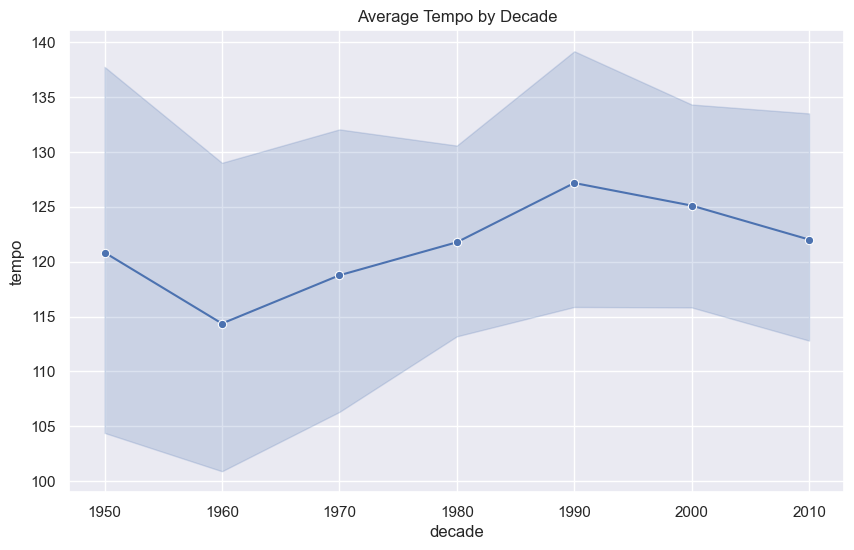

In [54]:
plt.figure(figsize=(10,6))
sns.lineplot(x="decade", y="tempo", data=df_all, marker="o", errorbar="ci")
plt.title("Average Tempo by Decade")
plt.savefig("docs/plots/tempo_trend.png", dpi=300, bbox_inches="tight")
plt.show()

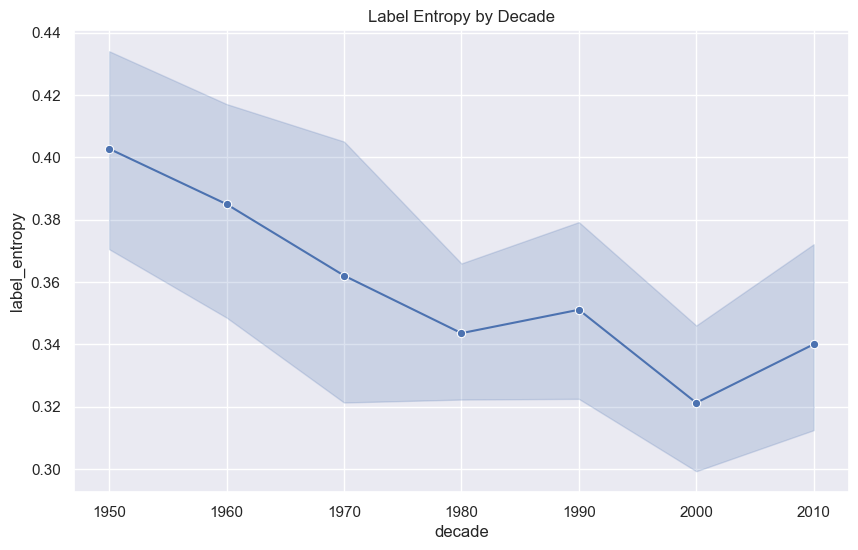

In [55]:
plt.figure(figsize=(10,6))
sns.lineplot(x="decade", y="label_entropy", data=df_all, marker="o", errorbar="ci")
plt.title("Label Entropy by Decade")
plt.savefig("docs/plots/label_entropy_trend.png", dpi=300, bbox_inches="tight")
plt.show()

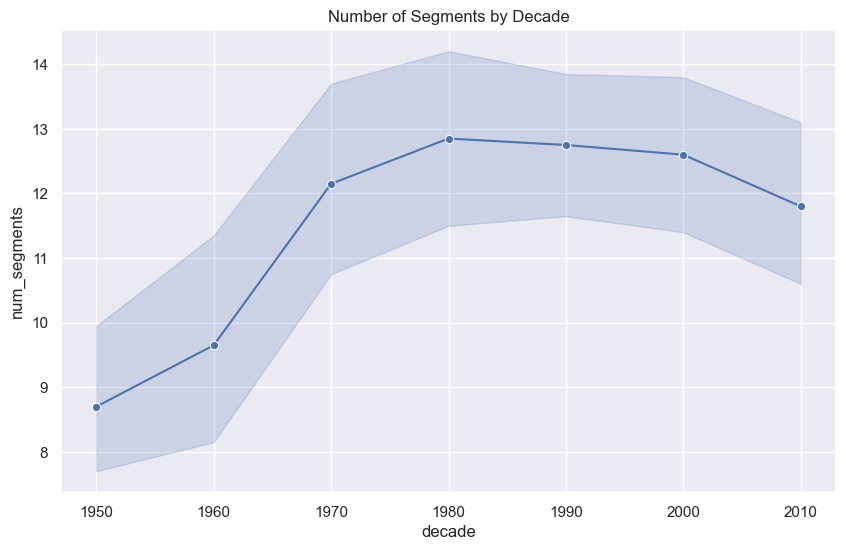

In [56]:
plt.figure(figsize=(10,6))
sns.lineplot(x="decade", y="num_segments", data=df_all, marker="o", errorbar="ci")
plt.title("Number of Segments by Decade")
plt.savefig("docs/plots/num_segments_trend.png", dpi=300, bbox_inches="tight")
plt.show()

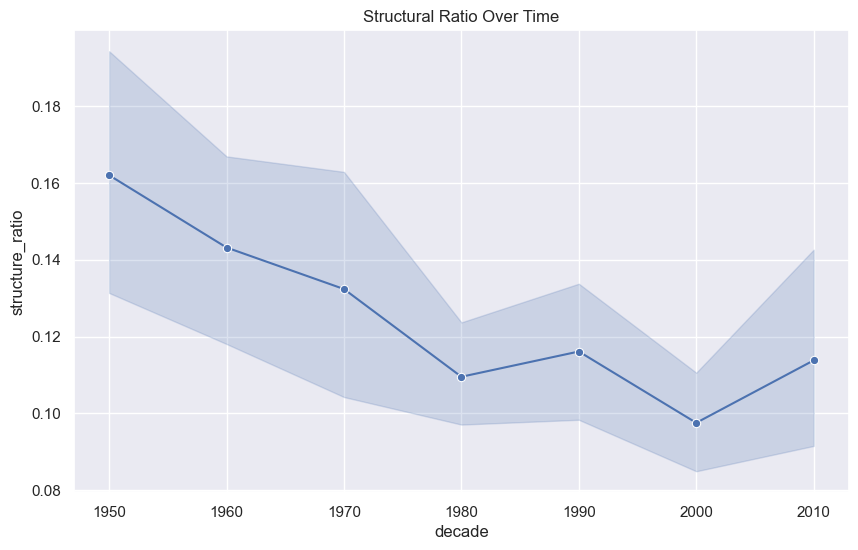

In [57]:
plt.figure(figsize=(10,6))
sns.lineplot(x="decade", y="structure_ratio", data=df_all, marker="o", errorbar="ci")
plt.title("Structural Ratio Over Time")
plt.savefig("docs/plots/structure_ratio_trend.png", dpi=300, bbox_inches="tight")
plt.show()

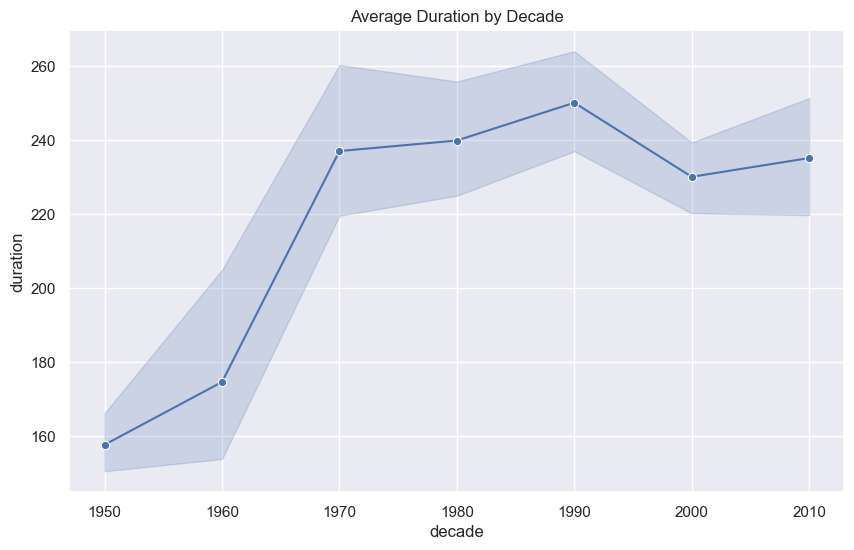

In [58]:
plt.figure(figsize=(10,6))
sns.lineplot(x="decade", y="duration", data=df_all, marker="o", errorbar="ci")
plt.title("Average Duration by Decade")
plt.savefig("docs/plots/duration_trend.png", dpi=300, bbox_inches="tight")
plt.show()

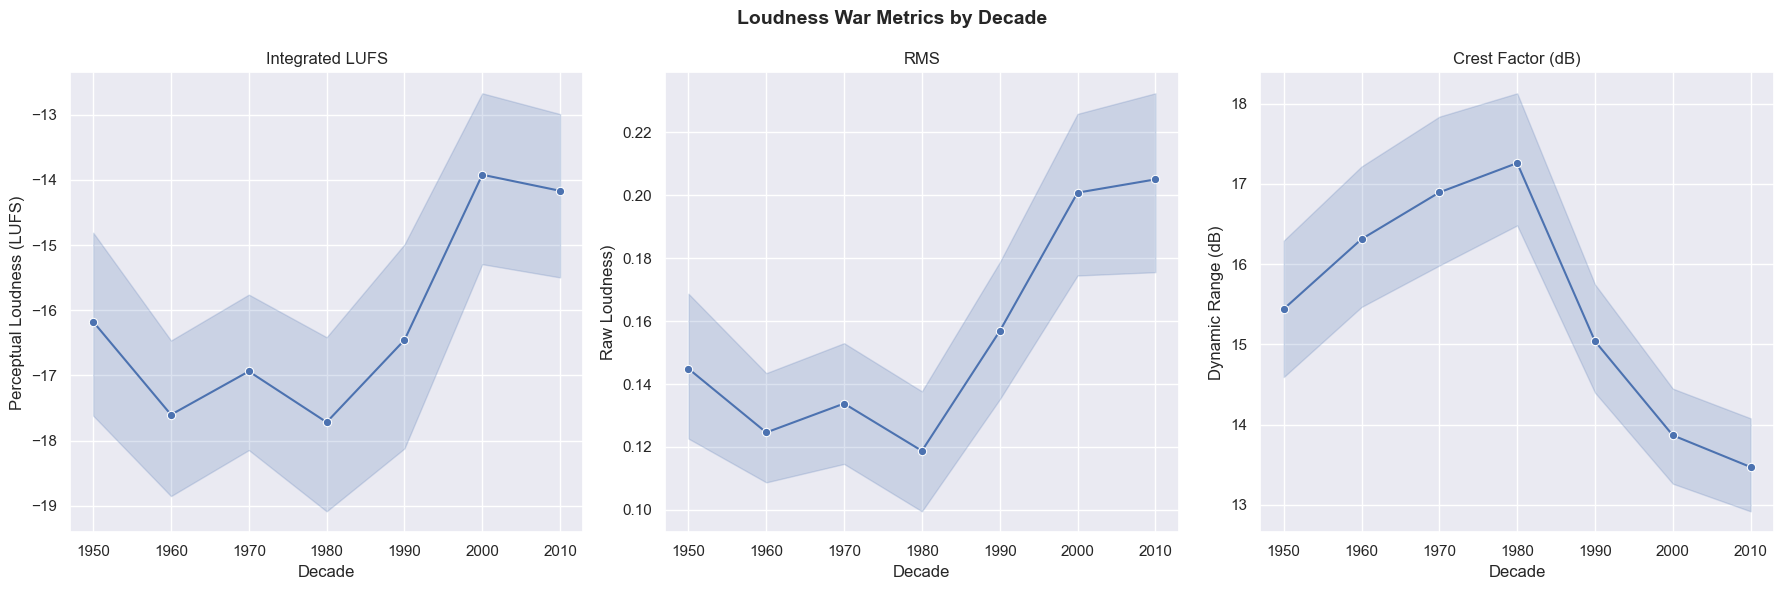

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = [
    ("lufs", "Integrated LUFS", "Perceptual Loudness (LUFS)"),
    ("rms_mean", "RMS", "Raw Loudness)"),
    ("crest_db", "Crest Factor (dB)", "Dynamic Range (dB)"),
]

for ax, (col, title, ylabel) in zip(axes, metrics):
    sns.lineplot(x="decade", y=col, data=df_all, marker="o", errorbar="ci", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Decade")
    ax.set_ylabel(ylabel)

fig.suptitle("Loudness War Metrics by Decade", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("docs/plots/loudness_trends.png", dpi=300, bbox_inches="tight")
plt.show()